<a href="https://www.kaggle.com/code/sonawanelalitsunil/students-performance-grading-dataset?scriptVersionId=223997458" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/students-grading-dataset/Students_Grading_Dataset.csv
/kaggle/input/students-grading-dataset/metadata.xlsx
/kaggle/input/students-grading-dataset/Students_Grading_Dataset.json


# Title:
### Students Performance and Grading Dataset for Data Science Analysis

## Description:

## This dataset contains detailed academic performance records of students, including their grades, attendance, study hours, extracurricular activities, and demographic information. It is designed for data science applications such as predictive analytics, machine learning, and educational insights.

#### The dataset can be used for various analyses, including:

Predicting student performance based on study habits and attendance.

Identifying key factors influencing academic success.

Analyzing trends in student grades across different subjects.

Detecting patterns in exam scores based on demographic attributes.

### Columns Overview:

Student ID – Unique identifier for each student.

Gender – Male, Female, or Other.

Age – Age of the student.

Parental Education Level – Highest education level of parents.

Study Hours per Week – Number of hours dedicated to studying.

Attendance Rate (%) – Percentage of classes attended.

Participation in Extracurricular Activities – Yes/No.

Assignment Scores – Average assignment performance.

Midterm Exam Scores – Score in midterm exams.

Final Exam Scores – Score in final exams.

Overall Grade – Final grade of the student (A, B, C, D, F).

Performance Category – Classification (e.g., Excellent, Good, Average, Poor).

step 1 : immport libraries

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

step 2 : import dataset

In [3]:
df = pd.read_csv("/kaggle/input/students-grading-dataset/Students_Grading_Dataset.csv")

In [4]:
df.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


In [5]:
df.tail()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
4995,S5995,Ahmed,Jones,student4995@university.com,Male,19,Business,NaN,82.15,60.33,...,58.42,85.21,D,25.5,No,Yes,High School,Low,10,8.3
4996,S5996,Emma,Brown,student4996@university.com,Male,19,Business,65.11,86.31,49.80,...,60.87,95.96,C,5.0,No,Yes,NaN,Medium,4,4.0
4997,S5997,John,Brown,student4997@university.com,Female,24,CS,87.54,63.55,64.21,...,82.65,54.25,A,24.8,Yes,No,High School,Medium,4,6.3
4998,S5998,Sara,Davis,student4998@university.com,Male,23,CS,92.56,79.79,94.28,...,94.29,55.84,A,16.1,Yes,Yes,Bachelor's,Low,1,8.4
4999,S5999,Maria,Brown,student4999@university.com,Female,21,Engineering,83.92,83.24,53.47,...,69.25,77.86,F,29.2,No,Yes,PhD,Low,2,6.1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   First_Name                  5000 non-null   object 
 2   Last_Name                   5000 non-null   object 
 3   Email                       5000 non-null   object 
 4   Gender                      5000 non-null   object 
 5   Age                         5000 non-null   int64  
 6   Department                  5000 non-null   object 
 7   Attendance (%)              4484 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             4483 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13  Projects_Score              5000 

In [7]:
df.describe()

,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night
count,5000.000000,4484.000000,5000.000000,5000.000000,4483.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,21.048400,75.431409,70.326844,69.640788,74.798673,74.910728,4.980024,74.924860,75.121804,17.658860,5.48080,6.488140
std,1.989786,14.372446,17.213209,17.238744,14.411799,14.504281,2.890136,14.423415,14.399941,7.275864,2.86155,1.452283
min,18.000000,50.010000,40.000000,40.000000,50.000000,50.030000,0.000000,50.010000,50.020000,5.000000,1.00000,4.000000
25%,19.000000,63.265000,55.457500,54.667500,62.090000,62.490000,2.440000,62.320000,62.835000,11.400000,3.00000,5.200000
50%,21.000000,75.725000,70.510000,69.735000,74.810000,74.695000,4.955000,74.980000,75.395000,17.500000,5.00000,6.500000
75%,23.000000,87.472500,84.970000,84.500000,86.970000,87.630000,7.500000,87.367500,87.652500,24.100000,8.00000,7.700000
max,24.000000,100.000000,99.980000,99.980000,99.980000,99.960000,10.000000,100.000000,99.990000,30.000000,10.00000,9.000000


In [8]:
df.dtypes

Student_ID                     object
First_Name                     object
Last_Name                      object
Email                          object
Gender                         object
Age                             int64
Department                     object
Attendance (%)                float64
Midterm_Score                 float64
Final_Score                   float64
Assignments_Avg               float64
Quizzes_Avg                   float64
Participation_Score           float64
Projects_Score                float64
Total_Score                   float64
Grade                          object
Study_Hours_per_Week          float64
Extracurricular_Activities     object
Internet_Access_at_Home        object
Parent_Education_Level         object
Family_Income_Level            object
Stress_Level (1-10)             int64
Sleep_Hours_per_Night         float64
dtype: object

In [9]:
df.isnull().sum()

Student_ID                       0
First_Name                       0
Last_Name                        0
Email                            0
Gender                           0
Age                              0
Department                       0
Attendance (%)                 516
Midterm_Score                    0
Final_Score                      0
Assignments_Avg                517
Quizzes_Avg                      0
Participation_Score              0
Projects_Score                   0
Total_Score                      0
Grade                            0
Study_Hours_per_Week             0
Extracurricular_Activities       0
Internet_Access_at_Home          0
Parent_Education_Level        1794
Family_Income_Level              0
Stress_Level (1-10)              0
Sleep_Hours_per_Night            0
dtype: int64

In [10]:
df.isnull().sum().sum()

2827

In [11]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

step 3: removing and handling missing values

In [12]:
df.drop(columns=['Student_ID', 'First_Name', 'Last_Name', 'Email'], inplace=True)

In [13]:
df.fillna(df.mean(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

In [14]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Gender', 'Department', 'Extracurricular_Activities', 'Internet_Access_at_Home','Parent_Education_Level', 'Family_Income_Level', 'Grade']

label_encoders = {col: LabelEncoder().fit(df[col]) for col in categorical_cols}

for col, le in label_encoders.items():
    df[col] = le.transform(df[col])

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_cols = ['Age', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 
                  'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score', 
                  'Study_Hours_per_Week', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night']

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Data visualization

In [16]:
df.columns

Index(['Gender', 'Age', 'Department', 'Attendance (%)', 'Midterm_Score',
       'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
       'Projects_Score', 'Total_Score', 'Grade', 'Study_Hours_per_Week',
       'Extracurricular_Activities', 'Internet_Access_at_Home',
       'Parent_Education_Level', 'Family_Income_Level', 'Stress_Level (1-10)',
       'Sleep_Hours_per_Night'],
      dtype='object')

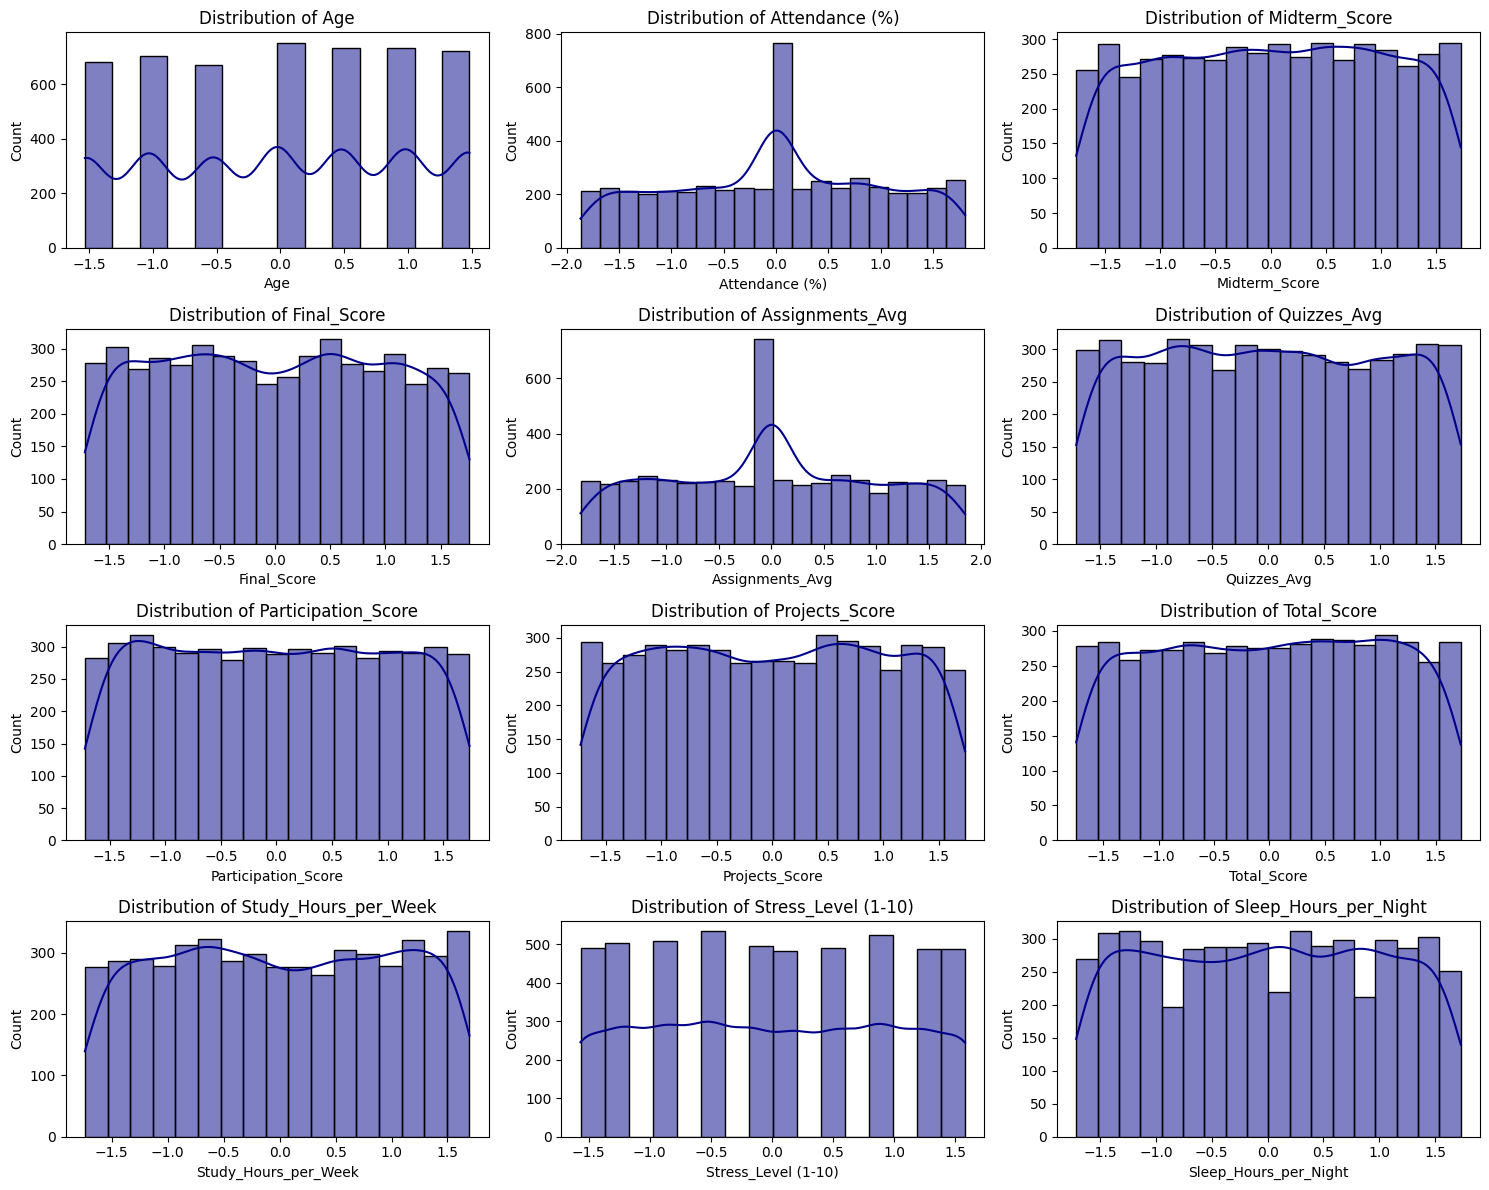

In [17]:
numerical_cols = ['Age', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 
                  'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score', 
                  'Study_Hours_per_Week', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night']

plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True, color='darkblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


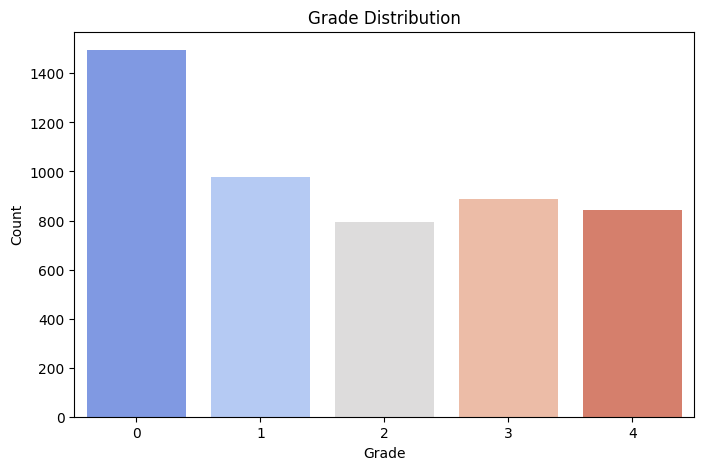

In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Grade', data=df, palette='coolwarm', order=sorted(df['Grade'].unique()))
plt.title('Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.show()

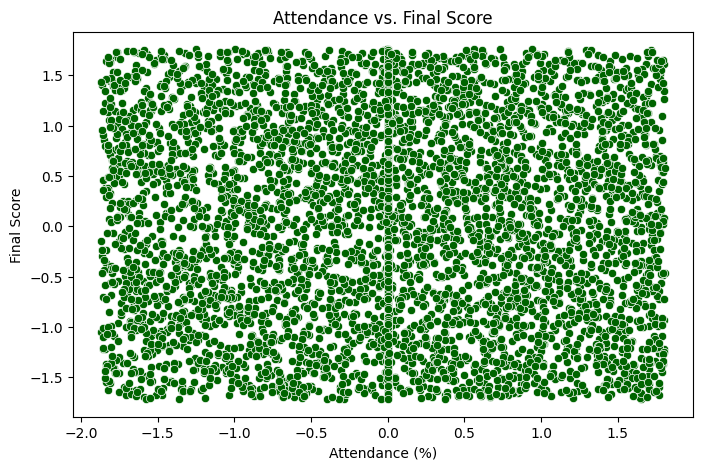

In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Attendance (%)', y='Final_Score', data=df, color='darkgreen')
plt.title('Attendance vs. Final Score')
plt.xlabel('Attendance (%)')
plt.ylabel('Final Score')
plt.show()

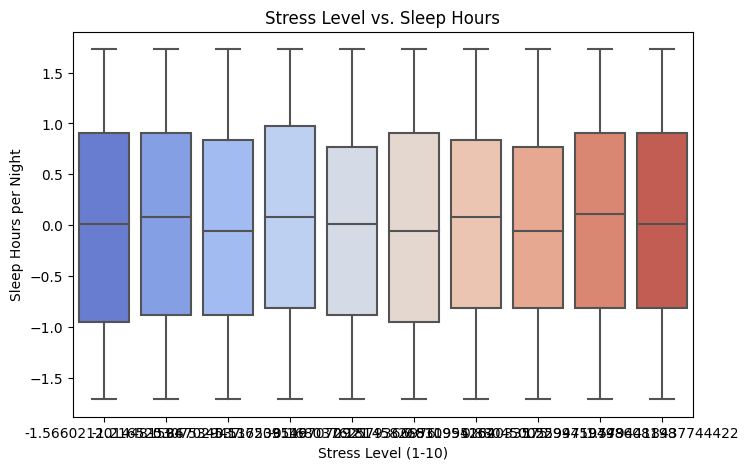

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Stress_Level (1-10)', y='Sleep_Hours_per_Night', data=df, palette='coolwarm')
plt.title('Stress Level vs. Sleep Hours')
plt.xlabel('Stress Level (1-10)')
plt.ylabel('Sleep Hours per Night')
plt.show()

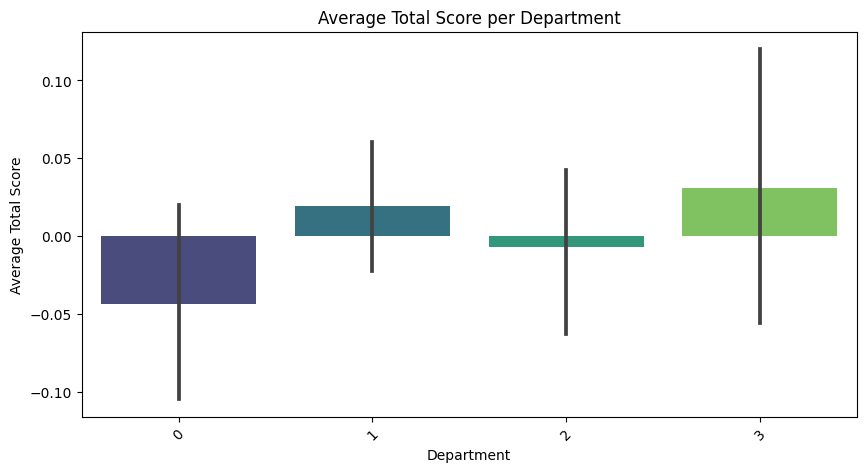

In [21]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Department', y='Total_Score', data=df, estimator=np.mean, palette='viridis')
plt.title('Average Total Score per Department')
plt.xticks(rotation=45)
plt.xlabel('Department')
plt.ylabel('Average Total Score')
plt.show()

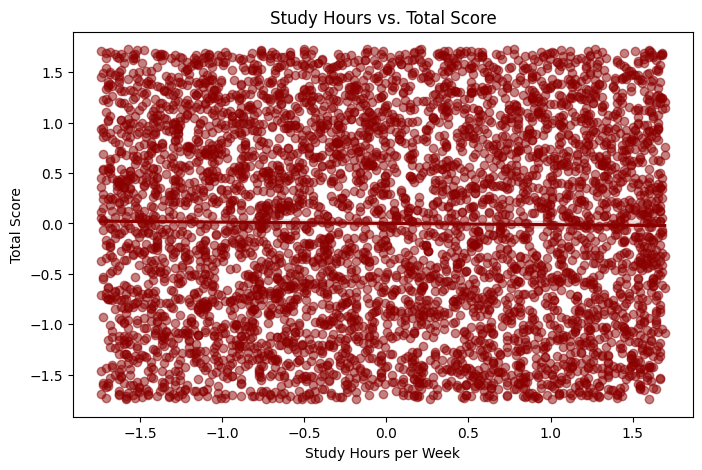

In [22]:
plt.figure(figsize=(8, 5))
sns.regplot(x='Study_Hours_per_Week', y='Total_Score', data=df, scatter_kws={'alpha':0.5}, color='darkred')
plt.title('Study Hours vs. Total Score')
plt.xlabel('Study Hours per Week')
plt.ylabel('Total Score')
plt.show()

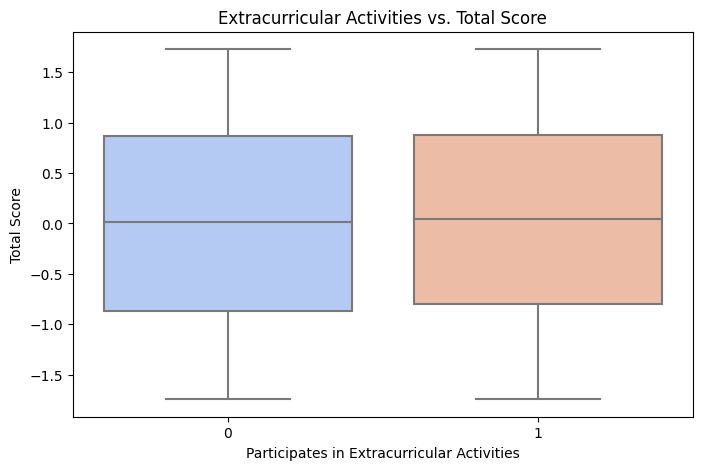

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Extracurricular_Activities', y='Total_Score', data=df, palette='coolwarm')
plt.title('Extracurricular Activities vs. Total Score')
plt.xlabel('Participates in Extracurricular Activities')
plt.ylabel('Total Score')
plt.show()

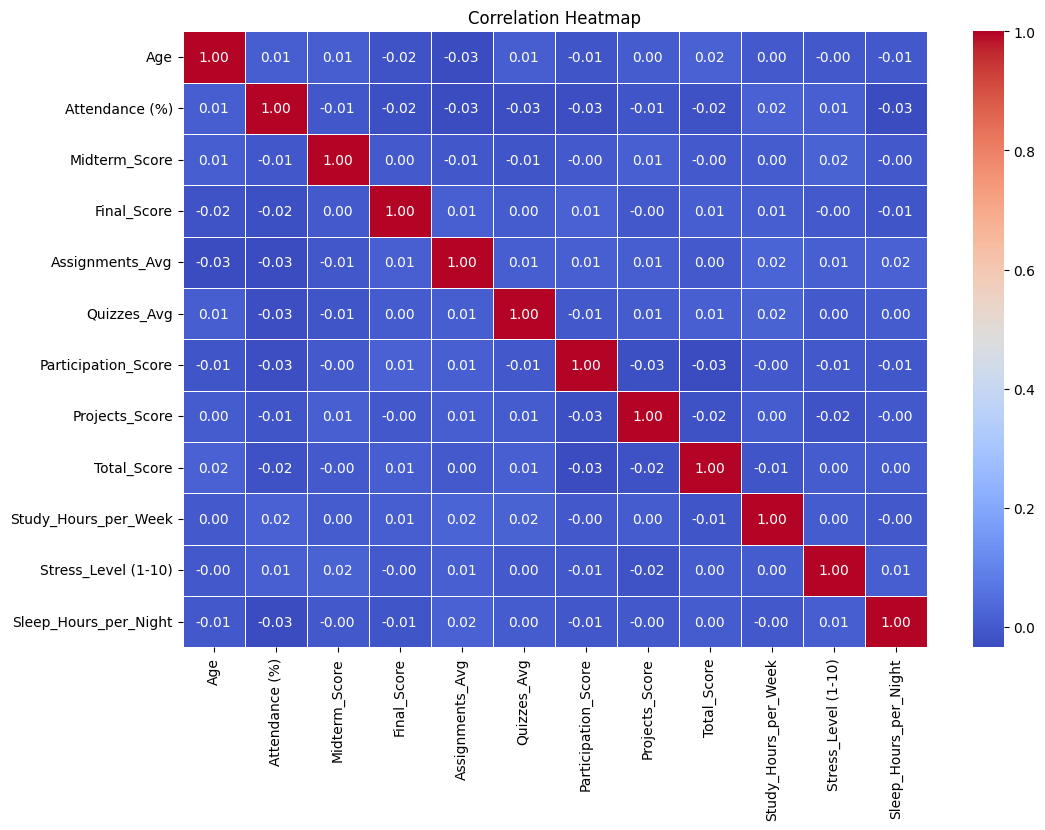

In [24]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## Ml Algorithms

In [25]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Grade'])
y = df['Grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=537, stratify=y)

In [26]:
import time
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [27]:
# Dictionary of models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(kernel='rbf', probability=True),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

In [28]:
# Train & Evaluate Models
ml_results = []

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)  # Train the model
    y_pred = model.predict(X_test)  # Predict on test set
    end_time = time.time()
    
    accuracy = accuracy_score(y_test, y_pred)  # Compute accuracy
    execution_time = end_time - start_time  # Measure training time
    
    ml_results.append([name, accuracy, execution_time])

    print(f"\nModel: {name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))

# Display results in a DataFrame
import pandas as pd
results_df = pd.DataFrame(ml_results, columns=["Model", "Accuracy", "Execution Time"])
print("\nFinal Model Performance:")
print(results_df)


Model: Random Forest
Accuracy: 0.3700
              precision    recall  f1-score   support

           0       0.59      0.70      0.64       299
           1       0.24      0.13      0.17       195
           2       0.19      0.18      0.18       159
           3       0.30      0.38      0.34       178
           4       0.25      0.25      0.25       169

    accuracy                           0.37      1000
   macro avg       0.31      0.32      0.31      1000
weighted avg       0.35      0.37      0.35      1000


Model: Gradient Boosting
Accuracy: 0.3630
              precision    recall  f1-score   support

           0       0.58      0.66      0.62       299
           1       0.30      0.17      0.22       195
           2       0.16      0.13      0.15       159
           3       0.31      0.40      0.35       178
           4       0.21      0.23      0.22       169

    accuracy                           0.36      1000
   macro avg       0.31      0.32      0.31      

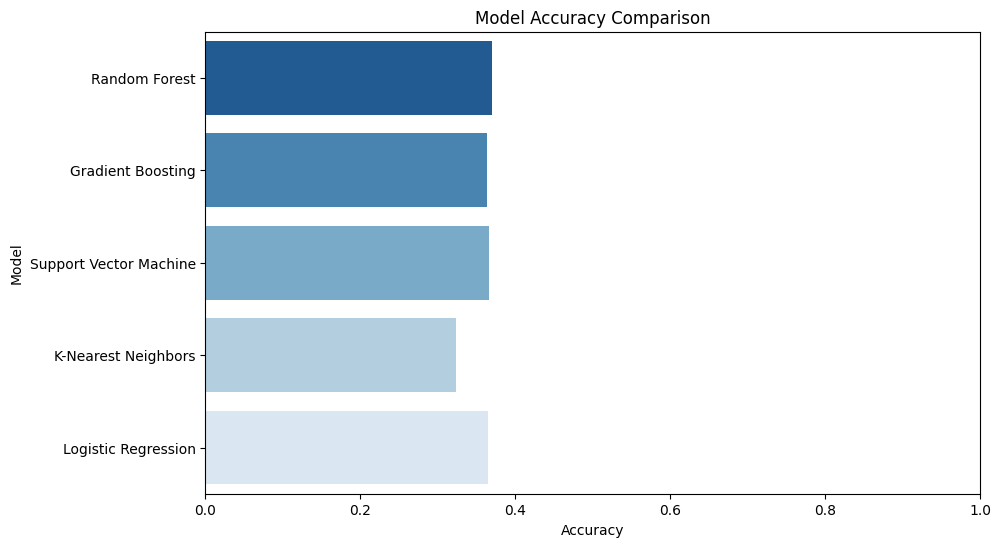

In [29]:
# Bar Plot - Model Accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x=results_df["Accuracy"], y=results_df["Model"], palette="Blues_r")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.title("Model Accuracy Comparison")
plt.xlim(0, 1)  # Accuracy ranges between 0 and 1
plt.show()

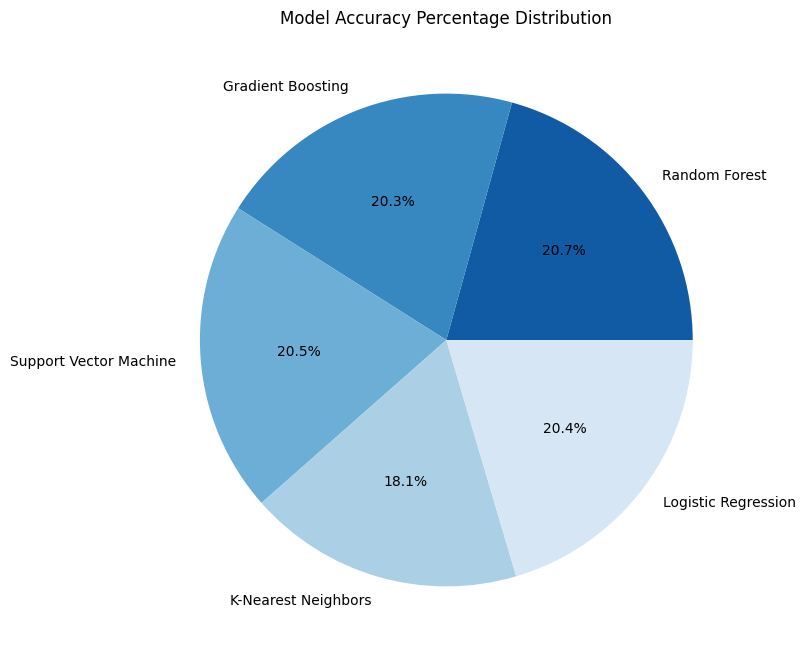

In [30]:
plt.figure(figsize=(8, 8))
plt.pie(results_df["Accuracy"], labels=results_df["Model"], autopct="%1.1f%%", colors=sns.color_palette("Blues_r", len(results_df)))
plt.title("Model Accuracy Percentage Distribution")
plt.show()

## Thank you...pls upvote...